# Experiment 1 — Activation steering

Reproduction guidebook §4.

> **Question.** *Where* — at which token positions and which layers — is confidence
> represented?
> **Key result.** Confidence is modulated at PANL (layers 21–25), then at CC (layers 30–35);
> control positions show no effect.

**Logic (§4.1).** If a verbally-reported sentiment (here: confidence) reflects access to a
meaningful internal signal, that signal must be instantiated as a direction in activation
space. Under the just-in-time account no sentiment-specific computation exists until CC, so
steering at PANL should be **ineffective**. Under cached retrieval it should work, and PANL effects should
emerge at **earlier layers** than CC effects. Both accounts predict steering at CC works, so
**CC alone is not diagnostic — PANL is.**

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vconf").is_dir())
sys.path.insert(0, str(ROOT))

from vconf import notebook as nb

from vconf import exp1_steering as E1
from vconf import metrics as M
from vconf import plotting, prompts
from vconf.results import compare_to_control, peak_layer, summarize

cfg = nb.run_config("gemma-categorical")
print(nb.describe(cfg))

profile          : reduced
model            : Qwen/Qwen2.5-7B-Instruct (28 layers)
prompt / dataset : categorical / triviaqa
layer sweep      : (0, 5, 11, 16, 22, 27)
trial counts     : {'steering': 24, 'patching': 24, 'noising': 32, 'swap': 24, 'attention': 24}
activation set   : 300   calibration set: 40
chat template    : True   attention impl: None
NOTE             : reduced profile — procedures, prompts, positions and
                   metrics follow the manual exactly, but the model and the
                   sample sizes are smaller than the paper's, so the numbers
                   here are not expected to match its reported values.


In [2]:
loaded = nb.open_model(cfg)
trials, rendered = nb.build_trials(loaded, cfg)
trials = nb.graded(trials)
print(len(trials), "trials |", nb.grader_note())

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

1000 trials | OPENAI_API_KEY is not set, so correctness labels come from the documented fallback (normalised alias matching), not the manual's gpt-4o-mini grader (§2.3.1) — accuracy/ECE/AUROC here are approximate for that reason


## The disjoint partition (§2.3.4)

Several sets must be **mutually disjoint**, partitioned once up front: the
**activation-collection set** (steering vectors, probes, the natural-variability
statistics), the **calibration set** (the means used for patching corruption and noising),
and the per-experiment **test sets**. `nb.split_activation_holdout` makes the first cut; the
balanced calibration set is then selected inside the holdout and the test trials from what is
left.

In [3]:
(act_trials, act_rendered), (hold_trials, hold_rendered) = nb.split_activation_holdout(
    trials, rendered, cfg
)
print(f"activation-collection set: {len(act_trials)} trials")
print(f"holdout (calibration + test): {len(hold_trials)} trials")
print("disjoint:", {t.qid for t in act_trials} & {t.qid for t in hold_trials} == set())

activation-collection set: 300 trials
holdout (calibration + test): 700 trials
disjoint: True


## Activation collection (§2.10)

One clean forward pass per trial with capture hooks, storing the residual stream at the
output of each swept decoder layer at every studied position. Everything downstream — the
steering vectors here, the probes of Experiment 6, the donors of Experiment 4 — reads this
store.

In [4]:
store = nb.activation_store(loaded, cfg, act_rendered, trials=act_trials)
print("layers   :", store.layers)
print("positions:", store.positions)
print("shape at (layer, PANL):", store.get(store.layers[-1], "PANL").shape)

layers   : (0, 5, 11, 16, 22, 27)
positions: ('PANL', 'PANL+1', 'CC', 'FCC', 'AC', 'first A', 'last A', 'QTT')
shape at (layer, PANL): (300, 3584)


## Building the steering vectors (§4.2)

From the activation-collection set, restricted to trials the model **answered correctly**:
`H` = the 25 highest-ranked trials, `L` = the 25 lowest-ranked. For each layer ℓ and
position p,

$$v_{\text{high}}^{(\ell,p)} = \mu(H)^{(\ell,p)} - \mu(L)^{(\ell,p)}, \qquad v_{\text{low}} = -v_{\text{high}}$$

**Normalization (critical).** Each vector is scaled to **3% of the mean residual norm** at
that (layer, position), then multiplied by α ∈ {2, 5}.

In [5]:
n_vector = 25 if nb.profile() == "paper" else 10
high_idx, low_idx = E1.select_vector_trials(act_trials, n=n_vector, require_correct=True)
vectors = E1.build_steering_vectors(store, high_idx, low_idx, cfg.steering_scale_fraction)

layer = cfg.layers[len(cfg.layers) // 2]
vector = vectors[(layer, "PANL")]
residual_norm = np.linalg.norm(store.get(layer, "PANL"), axis=-1).mean()
print(f"vectors built from {len(high_idx)} high + {len(low_idx)} low correct trials")
print(f"|v| at layer {layer}, PANL: {np.linalg.norm(vector):.3f}")
print(f"3% of the mean residual norm : {0.03 * residual_norm:.3f}")

vectors built from 10 high + 10 low correct trials
|v| at layer 16, PANL: 1.996
3% of the mean residual norm : 1.996


## Test trials (§4.4)

200 questions per layer per position in the paper, balanced: **half from the top-3
confidence classes, half from the bottom-3**, because the model favours high confidence.
Positions: PANL and CC (key), PANL+1 and FCC (controls). Directions: high and low.
Strengths: α ∈ {2, 5}.

In [6]:
index = E1.select_test_trials(hold_trials, cfg.trial_counts["steering"], model_key=cfg.model_key)
test_trials, test_rendered = nb.subset(hold_trials, hold_rendered, index)
bands = [prompts.CLASSES[t.class_index] for t in test_trials]
high_band, low_band = prompts.bands(cfg.model_key)
print(f"{len(test_trials)} steering-test trials: "
      f"{sum(b in high_band for b in bands)} high / {sum(b in low_band for b in bands)} low")
print("baseline confidence of the trial set:", np.mean([t.confidence for t in test_trials]).round(3),
      f"(paper: {E1.BASELINE_CONFIDENCE})")

24 steering-test trials: 12 high / 12 low
baseline confidence of the trial set: 0.5 (paper: 0.55)


In [7]:
frame = E1.run_steering(
    loaded, test_rendered, test_trials, vectors, cfg,
    positions=("PANL", "PANL+1", "CC", "FCC"),
)
summary = summarize(frame)
summary.head(12)

,position,condition,layer,n,confidence_change_mean,confidence_change_sem,logit_diff_change_mean,logit_diff_change_sem,token_changed_mean,token_changed_sem
0,CC,high α=2,0,24,0.000000,0.000000,-0.017072,0.015494,0.000000,0.000000
1,CC,high α=2,5,24,0.000000,0.000000,-0.004340,0.014683,0.000000,0.000000
2,CC,high α=2,11,24,0.008333,0.008333,-0.013600,0.020684,0.041667,0.041667
3,CC,high α=2,16,24,0.008333,0.008333,-0.116319,0.028988,0.041667,0.041667
4,CC,high α=2,22,24,0.075000,0.037227,-0.305845,0.182492,0.208333,0.084681
5,CC,high α=2,27,24,0.029167,0.016462,-0.169560,0.107917,0.125000,0.068960
6,CC,high α=5,0,24,0.000000,0.000000,-0.021123,0.015327,0.000000,0.000000
7,CC,high α=5,5,24,0.000000,0.000000,-0.027488,0.021152,0.000000,0.000000
8,CC,high α=5,11,24,0.016667,0.011526,-0.067130,0.037941,0.083333,0.057630
9,CC,high α=5,16,24,0.008333,0.008333,-0.312789,0.067059,0.041667,0.041667


## Δ confidence against layer, one panel per position (§4.5)

Error bars are SEM across trials; a condition counts as showing an effect only when it
separates from the PANL+1 control by clearly non-overlapping SEM bars (§2.8 (6)).

PosixPath('/scratch/qi/project/results/figures/exp1-steering-confidence-qwen-categorical-triviaqa-reduced.png')

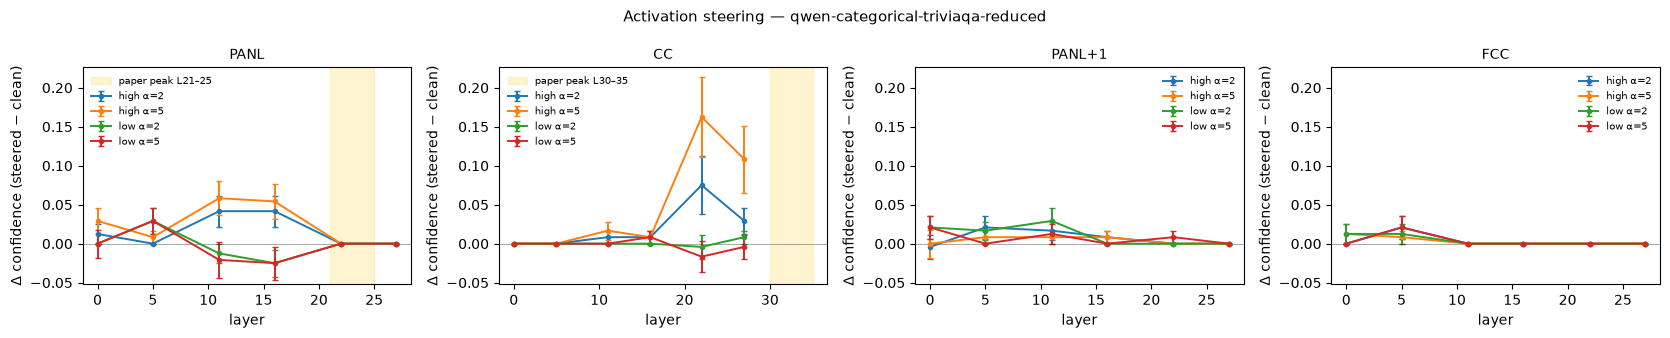

In [8]:
fig = plotting.position_panels(
    summary, "confidence_change", ("PANL", "CC", "PANL+1", "FCC"),
    ylabel="Δ confidence (steered − clean)", paper=E1.PAPER_TARGETS,
    suptitle=f"Activation steering — {cfg.name}",
)
plotting.save_figure(fig, f"exp1-steering-confidence-{cfg.name}")

PosixPath('/scratch/qi/project/results/figures/exp1-steering-logitdiff-qwen-categorical-triviaqa-reduced.png')

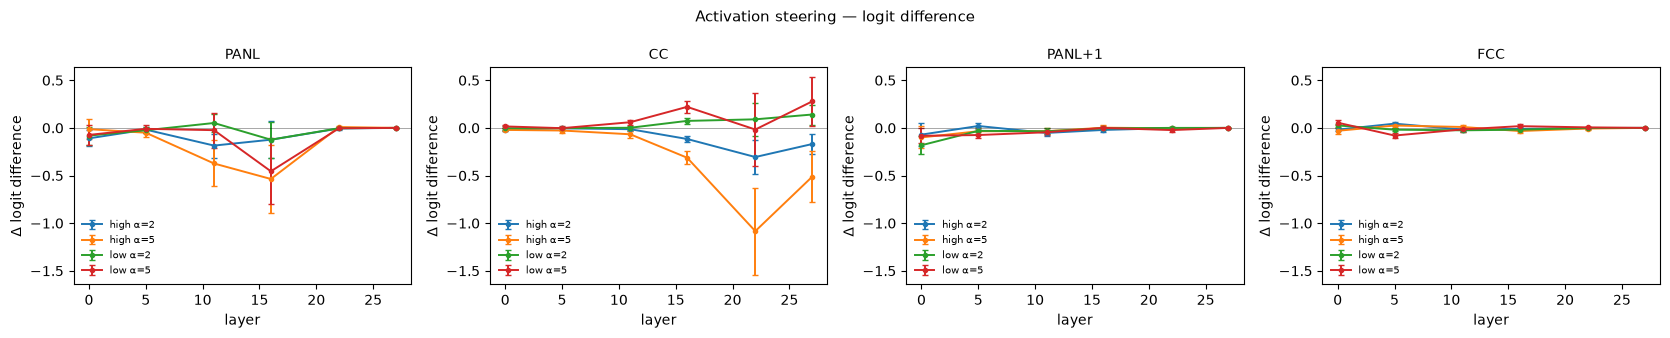

In [9]:
fig = plotting.position_panels(
    summary, "logit_diff_change", ("PANL", "CC", "PANL+1", "FCC"),
    ylabel="Δ logit difference", suptitle="Activation steering — logit difference",
)
plotting.save_figure(fig, f"exp1-steering-logitdiff-{cfg.name}")

## Peak layers — the temporal-precedence signature (§4.6)

The headline is not that steering works at CC (both accounts predict that) but that it works
at **PANL** and that PANL's effect peaks at **earlier layers** than CC's. If PANL and CC peak
at the same layer, something is wrong with the position indexing (§14.3).

In [10]:
peaks = {
    position: peak_layer(summary, "confidence_change", position)
    for position in ("PANL", "CC", "PANL+1", "FCC")
}
paper_peaks = E1.PEAK_LAYERS.get(
    "gemma-categorical" if cfg.model_key == "gemma" else "qwen-categorical", {}
)
pd.DataFrame(
    [{"position": p, "reproduction peak layer": peaks[p], "paper": paper_peaks.get(p)}
     for p in peaks]
)

,position,reproduction peak layer,paper
0,PANL,11,15.0
1,CC,22,22.0
2,PANL+1,11,1.0
3,FCC,5,NaN


In [11]:
print("PANL peaks before CC:", peaks["PANL"] < peaks["CC"])

for direction, alpha in [("high", cfg.steering_alphas[-1]), ("low", cfg.steering_alphas[-1])]:
    condition = f"{direction} α={alpha:g}"
    stats = compare_to_control(
        frame, "confidence_change", "PANL", control="PANL+1",
        layer=peaks["PANL"], condition=condition,
    )
    print(f"{condition:>12} PANL vs PANL+1 at L{peaks['PANL']}: "
          f"Δ = {stats['mean_difference']:+.3f} ± {stats['sem_difference']:.3f}, "
          f"t-test p = {stats['t_p']:.3g}, d = {stats['cohens_d']:.2f}")

PANL peaks before CC: True
    high α=5 PANL vs PANL+1 at L11: Δ = +0.050 ± 0.021, t-test p = 0.025, d = 0.49
     low α=5 PANL vs PANL+1 at L11: Δ = -0.033 ± 0.019, t-test p = 0.0881, d = -0.36


## Validation against §4.6

| Position | Effect | Peak layers | Magnitude (Δ confidence, α = 5) |
|---|---|---|---|
| **PANL** | strong, bidirectional, graded | **21–25** | high ≈ +0.15…+0.20; low ≈ −0.20 |
| **CC** | strong, bidirectional | **30–35** | high ≈ +0.40; low ≈ −0.40 |
| PANL+1 | null | — | ≈ ±0.02 (noise) |
| FCC | null | — | ≈ ±0.02 (noise) |

1. The **existence** of a PANL effect falsifies just-in-time computation. This is the headline.
2. The **temporal ordering** — PANL before CC — is the cached-retrieval signature.
3. **The controls must be null.** If PANL+1 shows effects the intervention is leaking.

In [12]:
rows = []
for position in ("PANL", "CC", "PANL+1", "FCC"):
    at_peak = summary[(summary["position"] == position)
                      & (summary["layer"] == peaks[position])]
    for direction in ("high", "low"):
        condition = f"{direction} α={cfg.steering_alphas[-1]:g}"
        row = at_peak[at_peak["condition"] == condition]
        if row.empty:
            continue
        rows.append({
            "position": position, "direction": direction, "layer": peaks[position],
            "Δ confidence": round(float(row["confidence_change_mean"].iloc[0]), 4),
            "SEM": round(float(row["confidence_change_sem"].iloc[0]), 4),
            "paper": E1.PAPER_TARGETS[position][f"delta_{direction}"],
        })
pd.DataFrame(rows)

,position,direction,layer,Δ confidence,SEM,paper
0,PANL,high,11,0.0583,0.0216,0.175
1,PANL,low,11,-0.0208,0.0233,-0.200
2,CC,high,22,0.1625,0.0514,0.400
3,CC,low,22,-0.0167,0.0197,-0.400
4,PANL+1,high,11,0.0083,0.0083,0.020
5,PANL+1,low,11,0.0125,0.0125,-0.020
6,FCC,high,5,0.0083,0.0083,0.020
7,FCC,low,5,0.0208,0.0147,-0.020


In [13]:
control_peak = max(
    abs(summary[summary["position"] == p]["confidence_change_mean"]).max()
    for p in ("PANL+1", "FCC")
)
panl_peak = abs(summary[summary["position"] == "PANL"]["confidence_change_mean"]).max()
cc_peak = abs(summary[summary["position"] == "CC"]["confidence_change_mean"]).max()

checks = {
    "Q1 steering at PANL modulates confidence": panl_peak > control_peak,
    "Q2 PANL+1 and FCC are null relative to PANL": control_peak < panl_peak,
    "Q3 PANL peaks at an earlier layer than CC": peaks["PANL"] < peaks["CC"],
    "steering at CC is effective (not diagnostic, but expected)": cc_peak > control_peak,
}
for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")

PASS  Q1 steering at PANL modulates confidence
PASS  Q2 PANL+1 and FCC are null relative to PANL
PASS  Q3 PANL peaks at an earlier layer than CC
PASS  steering at CC is effective (not diagnostic, but expected)


**Interpretation.** A steerable confidence direction at the post-answer newline — a
position the model reached *before* it could know a confidence rating would be requested —
is incompatible with just-in-time computation. The control position one token away shows
nothing, so the effect is not generic disruption; Experiment 5 confirms that quantitatively
by showing PANL and PANL+1 drift out of distribution by the *same* amount.